<a href="https://colab.research.google.com/github/AkshitaNipane/Machine-Learning-TAE/blob/main/MODEL_4_ML_TAE(logisticRegression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
df = pd.read_csv('/content/customer_feedback_satisfaction.csv')
df.head()

,CustomerID,Age,Gender,Country,Income,ProductQuality,ServiceQuality,PurchaseFrequency,FeedbackScore,LoyaltyLevel,SatisfactionScore
0,1,56,Male,UK,83094,5,8,5,Low,Bronze,100.0
1,2,69,Male,UK,86860,10,2,8,Medium,Gold,100.0
2,3,46,Female,USA,60173,8,10,18,Medium,Silver,100.0
3,4,32,Female,UK,73884,7,10,16,Low,Gold,100.0
4,5,60,Male,UK,97546,6,4,13,Low,Bronze,82.0


In [24]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38444 entries, 0 to 38443
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         38444 non-null  int64  
 1   Age                38444 non-null  int64  
 2   Gender             38444 non-null  object 
 3   Country            38444 non-null  object 
 4   Income             38444 non-null  int64  
 5   ProductQuality     38444 non-null  int64  
 6   ServiceQuality     38444 non-null  int64  
 7   PurchaseFrequency  38444 non-null  int64  
 8   FeedbackScore      38444 non-null  object 
 9   LoyaltyLevel       38444 non-null  object 
 10  SatisfactionScore  38444 non-null  float64
dtypes: float64(1), int64(6), object(4)
memory usage: 3.2+ MB


,0
CustomerID,0
Age,0
Gender,0
Country,0
Income,0
ProductQuality,0
ServiceQuality,0
PurchaseFrequency,0
FeedbackScore,0
LoyaltyLevel,0


In [25]:
# Fill missing values
df.fillna(method='ffill', inplace=True)

# Convert categorical columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

/tmp/ipykernel_18354/2707498590.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


,CustomerID,Age,Gender,Country,Income,ProductQuality,ServiceQuality,PurchaseFrequency,FeedbackScore,LoyaltyLevel,SatisfactionScore
0,1,56,1,3,83094,5,8,5,1,0,100.0
1,2,69,1,3,86860,10,2,8,2,1,100.0
2,3,46,0,4,60173,8,10,18,2,2,100.0
3,4,32,0,3,73884,7,10,16,1,1,100.0
4,5,60,1,3,97546,6,4,13,1,0,82.0


In [26]:
X = df.drop('SatisfactionScore', axis=1)
y = df['SatisfactionScore']

print(X.head())
print(y.head())

   CustomerID  Age  Gender  Country  Income  ProductQuality  ServiceQuality  \
0           1   56       1        3   83094               5               8   
1           2   69       1        3   86860              10               2   
2           3   46       0        4   60173               8              10   
3           4   32       0        3   73884               7              10   
4           5   60       1        3   97546               6               4   

   PurchaseFrequency  FeedbackScore  LoyaltyLevel  
0                  5              1             0  
1                  8              2             1  
2                 18              2             2  
3                 16              1             1  
4                 13              1             0  
0    100.0
1    100.0
2    100.0
3    100.0
4     82.0
Name: SatisfactionScore, dtype: float64


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [28]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [29]:
from sklearn.model_selection import GridSearchCV

parameters = {
    'fit_intercept': [True, False],
    'copy_X': [True, False]
}

grid = GridSearchCV(model, param_grid=parameters, scoring='neg_mean_squared_error', cv=5)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LinearRegression(),
             param_grid={'copy_X': [True, False],
                         'fit_intercept': [True, False]},
             scoring='neg_mean_squared_error')

In [30]:
print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'copy_X': True, 'fit_intercept': True}
Best Score: -85.93791027328352


In [31]:
y_pred = grid.predict(X_test)

In [32]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Evaluate the model using regression metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Squared Error: 85.07
Mean Absolute Error: 7.38
R-squared: 0.70


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

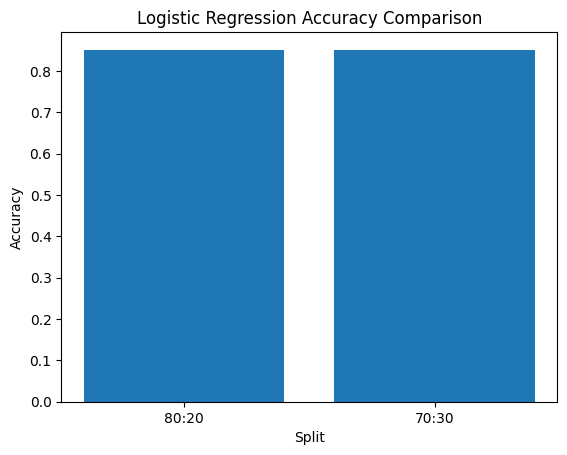

In [38]:
log_acc_80, _ = log_model(0.8)
log_acc_70, _ = log_model(0.7)

plt.bar(['80:20','70:30'], [log_acc_80, log_acc_70])
plt.title("Logistic Regression Accuracy Comparison")
plt.xlabel("Split")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

def log_model(train_split_ratio):
    test_size = 1 - train_split_ratio

    # Convert y to a categorical variable for Logistic Regression
    # Example: if SatisfactionScore >= 80, categorize as 1 (High), else 0 (Low)
    y_categorical = (y >= 80).astype(int)

    x_train_split, x_test_split, y_train_split, y_test_split = train_test_split(
        X, y_categorical, test_size=test_size, random_state=42, stratify=y_categorical
    )

    # Scale the features
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train_split)
    x_test_scaled = scaler.transform(x_test_split)

    model_split = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
    model_split.fit(x_train_scaled, y_train_split)

    y_pred_split = model_split.predict(x_test_scaled)

    acc_split = accuracy_score(y_test_split, y_pred_split)

    metrics_table = {
        "Accuracy": acc_split
    }

    return acc_split, metrics_table